In [ ]:
# PCA - Principal Component Ananlysis - Dimension Reduction Algo.

import yfinance as yf

ticker = "AAPL"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

/tmp/ipykernel_1872/2940721337.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


In [ ]:
df["return_5d"] = (
    df["Close"] /
    df["Close"].shift(5)
) - 1

In [ ]:
df["return_20d"] = (
    df["Close"] /
    df["Close"].shift(20)
) - 1

In [ ]:
df["volatility_20d"] = (
    df["Close"]
    .pct_change()
    .rolling(20)
    .std()
)

In [ ]:
df["volume_ratio"] = (
    df["Volume"] /
    df["Volume"].rolling(20).mean()
)

In [ ]:
df["target"] = (
    df["Close"].shift(-1)
    / df["Close"]
) - 1

In [ ]:
features = [
    "return_5d",
    "return_20d",
    "volatility_20d",
    "volume_ratio"
]

df = df.dropna()

X = df[features]
y = df["target"]

In [ ]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
pred_train = model.predict(X_train)

pred_test = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

train_r2 = r2_score(
    y_train,
    pred_train
)

test_r2 = r2_score(
    y_test,
    pred_test
)

print(train_r2)
print(test_r2)

0.003007322673209578
-0.00792198708447267


In [ ]:
from sklearn.tree import (
    DecisionTreeRegressor
)

tree = DecisionTreeRegressor(
    max_depth=3
)

tree.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(max_depth=3)

In [ ]:
tree_train = tree.predict(X_train)

tree_test = tree.predict(X_test)

In [ ]:
print(
    r2_score(y_train, tree_train)
)

print(
    r2_score(y_test, tree_test)
)

0.07731541215916815
-1.0422009090627071e-05


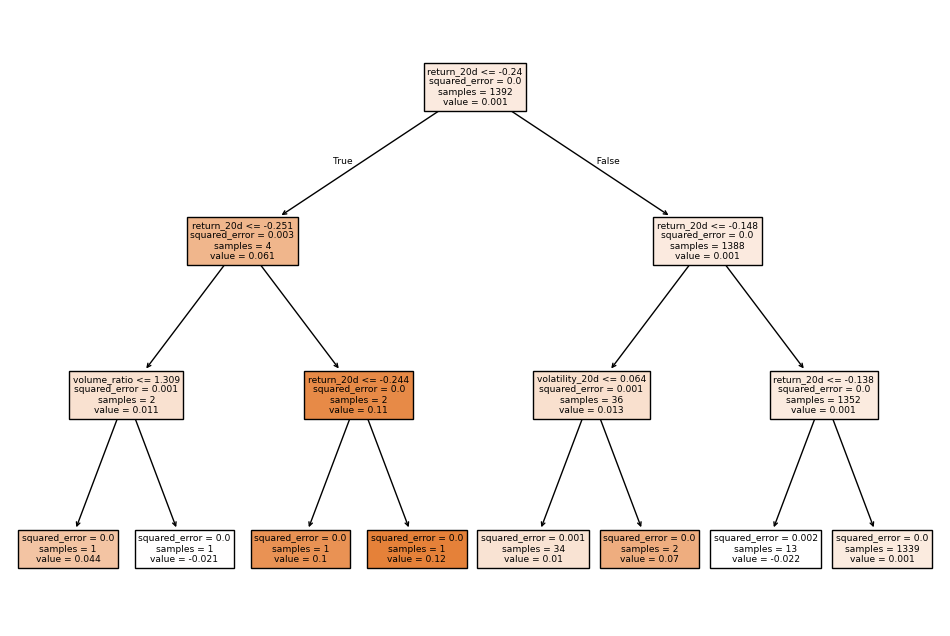

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,8)
)

plot_tree(
    tree,
    feature_names=features,
    filled=True
)

plt.show()

In [ ]:
overfit_tree = (
    DecisionTreeRegressor(
        max_depth=20
    )
)

<Axes: >

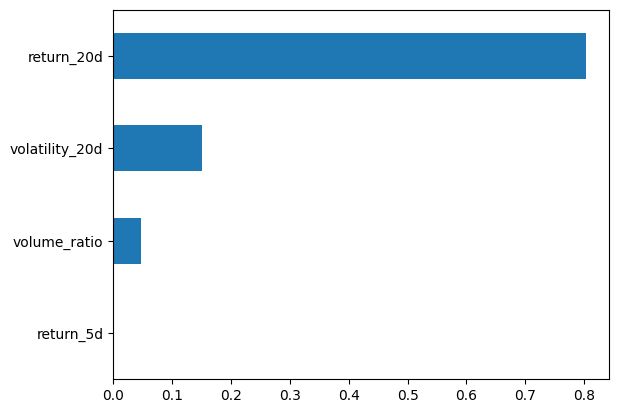

In [ ]:
import pandas as pd

importance = pd.Series(
    tree.feature_importances_,
    index=features
)

importance.sort_values().plot.barh()